In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

In [2]:
#Values from DNS
beta = np.pi/2
a =.3
eta = 5e-3
c = 9.65
d = .05
kappa = .09 

In [3]:
def A(q):
    return a * (np.sqrt(q**2 + eta**2) - eta)

def dA(q):
    return a*q / np.sqrt(q**2+eta**2)

def nuT(q,Re):
    return d*Re*q

In [4]:
def u_from_u_nullcline(q, Re, drag):
    # u̇ = (beta²/Re)(1-u) + alpha*(h(1) - h(u)) - beta*A(q) = 0
    # Note: h(1) - h(u) ensures the body force cancels drag at u=1 exactly
    alpha = drag['alpha']
    h     = drag['h']
    h1    = float(h(1.0))    # h evaluated at the laminar state u=1

    def udot_zero(u):
        # This equals zero when u̇ = 0 for a given value of q
        return (beta**2/Re)*(1 - u) + alpha*(h1 - h(u)) - beta*A(q)

    if np.isscalar(q):
        # Scalar input: solve once
        try:
            return brentq(udot_zero, 0.01, 1.5)
        except ValueError:
            return np.nan    # no root found in this range

    else:
        # Array input: solve for each q value one at a time
        result = np.zeros_like(q, dtype=float)
        for idx, q_val in enumerate(q):
            def udot_zero_scalar(u):
                return (beta**2/Re)*(1 - u) + alpha*(h1 - h(u)) - beta*A(q_val)
            try:
                result[idx] = brentq(udot_zero_scalar, 0.01, 1.5)
            except ValueError:
                result[idx] = np.nan
        return result


def u_from_q_nullcline(q, Re, drag):
    # The q-nullcline for q > 0: value of u where q̇ = 0
    # The TKE equation drag is -2*alpha*q (always linear in q)
    # so this formula does not change with drag type
    alpha = drag['alpha']
    return 2.0 * (2*alpha + c/Re) * q / (beta * A(q))


def find_roots(f, q_scan):
    # Finds all q values where f(q) = 0 by scanning for sign changes
    # then pinning down each root precisely using brentq
    fv = np.array([f(q) for q in q_scan])    # evaluate f at every scan point
    roots = []
    for i in range(len(q_scan) - 1):
        if np.isnan(fv[i]) or np.isnan(fv[i+1]):
            continue    # skip intervals containing NaN
        if fv[i] * fv[i+1] < 0:    # sign change means a root exists here
            try:
                roots.append(brentq(f, q_scan[i], q_scan[i+1]))
            except Exception:
                pass    # skip quietly if brentq fails
    return roots


def find_upper_branch(Re, drag):
    # Finds (uss, qss) for the upper-branch turbulent steady state at this Re
    # The upper branch is the high-turbulence solution — top of the S-curve
    # Returns (None, None) if no turbulent state exists at this Re

    def mismatch(q):
        # Zero where both nullclines cross — i.e. at a steady state
        u_unc = u_from_u_nullcline(q, Re, drag)
        u_qnc = u_from_q_nullcline(q, Re, drag)
        if np.isnan(u_unc):
            return np.nan
        return u_unc - u_qnc

    q_scan = np.linspace(1e-4, 0.12, 4000)    # fine scan over a wide q range
    roots  = find_roots(mismatch, q_scan)

    if not roots:
        return None, None    # no turbulent state at this Re

    q_upper = max(roots)     # upper branch = largest q root
    u_upper = u_from_u_nullcline(q_upper, Re, drag)
    return u_upper, q_upper

In [5]:
def build_matrix(kx, kz, Re, uss, qss, drag, lw=False):

    alpha  = drag['alpha']
    alpha0 = drag['alpha0']
    dh     = drag['dh']

    alpha_eff = alpha * float(dh(np.array([uss]))[0])

    k2  = max(kx**2 + kz**2, 1e-20)    # k², guard against division by zero at k=0
    kb2 = k2 + beta**2                  # k² + β², appears in the full equations

    # Evaluate closures at the turbulent steady state
    Ass  = A(qss)          # Reynolds stress amplitude at steady state
    Apps = dA(qss)         # its derivative — appears in the linearised equations
    epsp = c / Re          # derivative of ε₀ with respect to q (linear in q)
    nT   = nuT(qss, Re)    # turbulent diffusivity at steady state

    # ∂q̇₀/∂q₀ at steady state — equation B3
    # Uses alpha_eff throughout to correctly account for nonlinear drag
    Dq = (0.5*beta*uss*Apps - 2*alpha_eff - epsp
          - k2/Re - nT*k2
          - uss**2 * kx**2 / (2*(2*alpha_eff + kappa + beta**2/Re)))

    # Initialise a 6x6 matrix of zeros
    # dtype=complex because eigenvalues can in general be complex numbers
    M = np.zeros((6, 6), dtype=complex)

    if lw:
        # ── Long-wavelength approximation (equation B4) ────────────────────
        # Terms of order (k/β)² dropped as negligible when k ≪ β

        M[0,0] = -alpha0                               # Ekman drag on bulk mode
        M[0,1] = -0.5j * kx * uss                     # advection of û₁
        M[0,2] = beta * uss * (kx**2/k2 - 0.5)        # pressure minus advection

        M[1,0] = -1j * kx * uss                        # advection of û₀
        M[1,1] = -(alpha_eff + beta**2/Re)             # linearised drag + viscous
        M[1,5] = -beta * Apps                          # Reynolds stress from q̂₀

        M[2,2] = -(alpha_eff + beta**2/Re)             # linearised drag + viscous
        M[2,5] = -1j * kx * Apps                      # Reynolds stress from q̂₀

        M[3,2] = beta * uss * kx * kz / k2            # pressure from v̂₁
        M[3,3] = -alpha0                               # Ekman drag on bulk mode
        M[3,4] = -0.5j * kx * uss                     # advection of ŵ₁

        M[4,3] = -1j * kx * uss                        # advection of ŵ₀
        M[4,4] = -(alpha_eff + beta**2/Re)             # linearised drag + viscous

        M[5,1] = 0.5 * beta * Ass                     # TKE production from û₁
        M[5,5] = Dq                                    # all other TKE terms

        return M

    # ── Full system (equation B1) ──────────────────────────────────────────

    M[0,0] = -(k2/Re + alpha0)                        # viscous + Ekman drag
    M[0,1] = -0.5j * kx * uss                         # advection of û₁
    M[0,2] = beta * uss * (kx**2/k2 - 0.5)            # pressure minus advection

    M[1,0] = -1j * kx * uss                            # advection of û₀
    M[1,1] = -(kb2/Re + alpha_eff)                    # 3D viscous + linearised drag
    M[1,2] = -1j * kx * alpha_eff * beta / kb2        # pressure-drag cross term
    M[1,5] = -(1 - 2*kx**2/kb2) * beta * Apps        # projected Reynolds stress

    M[2,2] = -(alpha_eff*beta**2/kb2 + kb2/Re)        # projected drag + viscous
    M[2,5] = (1 - 2*beta**2/kb2) * 1j * kx * Apps    # projected Reynolds stress

    M[3,2] = kx*kz*beta*uss/k2                        # pressure from v̂₁
    M[3,3] = -(k2/Re + alpha0)                        # viscous + Ekman drag
    M[3,4] = -0.5j * kx * uss                         # advection of ŵ₁

    M[4,2] = -1j * kz * alpha_eff * beta / kb2        # pressure-drag cross term
    M[4,3] = -1j * kx * uss                            # advection of ŵ₀
    M[4,4] = -(kb2/Re + alpha_eff)                    # 3D viscous + linearised drag
    M[4,5] = 2*kx*kz*beta*Apps/kb2                    # off-diagonal Reynolds stress

    M[5,1] = 0.5 * beta * Ass                         # TKE production from û₁
    M[5,2] = 0.5 * Ass * 1j * kx                      # TKE production from v̂₁
    M[5,5] = Dq                                        # all other TKE terms

    return M


def compute_growth_map(kx_arr, kz_arr, Re, drag, lw=False):
    # Sweeps over all (kx, kz) pairs and records the maximum growth rate

    uss, qss = find_upper_branch(Re, drag)

    if uss is None:
        raise ValueError(
            f"No upper-branch state at Re={Re} for '{drag['name']}' drag")

    # Pre-allocate output array — rows = kz, columns = kx
    growth = np.zeros((len(kz_arr), len(kx_arr)))

    for j, kz in enumerate(kz_arr):
        for i, kx in enumerate(kx_arr):
            M = build_matrix(kx, kz, Re, uss, qss, drag, lw=lw)
            growth[j,i] = np.max(np.real(np.linalg.eigvals(M)))

    return growth

In [6]:
def viability_scan(drag, Re_range):

    print(f"\nViability scan — {drag['name']} drag")
    print(f"  alpha = {drag['alpha']:.5f},  "
          f"h(1) = {float(drag['h'](1.0)):.4f},  "
          f"dh(1) = {float(drag['dh'](np.array([1.0]))[0]):.4f}")
    print(f"\n{'Re':>6}  {'uss':>8}  {'qss':>10}  "
          f"{'max_growth':>12}  {'status':>15}")
    print("-" * 60)

    # Coarse wavenumber grid — fine enough to detect instability without being slow
    kx_test = np.linspace(0.001, 0.3, 60)
    kz_test = np.linspace(0.001, 0.5, 60)

    # Store results so we can detect the positive-to-negative transition
    results = []

    for Re in Re_range:

        uss, qss = find_upper_branch(Re, drag)

        if uss is None:
            # No turbulent state at this Re — below Re_sn
            results.append((Re, None, None, None))
            continue

        try:
            # Suppress the internal print from compute_growth_map
            G     = compute_growth_map(kx_test, kz_test, Re, drag, lw=False)
            max_g = np.max(G)
        except Exception as e:
            results.append((Re, uss, qss, None))
            continue

        results.append((Re, uss, qss, max_g))

    # Now go through results and assign status labels
    # Re_c is where growth rate crosses from positive (below) to negative (above)
    # i.e. the LAST Re with positive growth rate before it turns negative
    rec_idx = None
    for i in range(len(results) - 1):
        Re_i,   uss_i,   qss_i,   mg_i   = results[i]
        Re_ip1, uss_ip1, qss_ip1, mg_ip1 = results[i+1]
        # Both must have valid growth rates to compare
        if mg_i is not None and mg_ip1 is not None:
            # Sign change from positive to negative going upward in Re
            if mg_i > 0 and mg_ip1 <= 0:
                rec_idx = i    # Re_c is between results[i] and results[i+1]

    # Print all results with correct labels
    for idx, (Re, uss, qss, max_g) in enumerate(results):

        if uss is None:
            print(f"{Re:>6}  {'---':>8}  {'---':>10}  "
                  f"{'---':>12}  {'no turb state':>15}")
            continue

        if max_g is None:
            print(f"{Re:>6}  {uss:>8.4f}  {qss:>10.5f}  "
                  f"{'error':>12}  {'error':>15}")
            continue

        # Assign status
        if idx == rec_idx:
            # This is the last Re with positive growth rate — Re_c is just above here
            status = f'Re_c ~ {results[idx+1][0]}'
        elif max_g > 0:
            status = 'unstable (bands)'     # below Re_c, patterns expected
        else:
            status = 'stable'               # above Re_c, uniform turbulence

        print(f"{Re:>6}  {uss:>8.4f}  {qss:>10.5f}  "
              f"{max_g:>12.5f}  {status:>15}")

    # Print a summary of the key values
    print("\nSummary:")

    # Re_sn: last Re with no turb state
    no_turb = [r[0] for r in results if r[1] is None]
    has_turb = [r[0] for r in results if r[1] is not None]
    if no_turb and has_turb:
        print(f"  Re_sn is between Re={max(no_turb)} and Re={min(has_turb)}")
        print(f"  Use Re_low  = {min(has_turb)} for Figure 6 phase plane")
        print(f"  Use Re_stable = {min(has_turb)} for Figure 10 panel (a)")

    # Re_c: where growth rate crosses zero
    if rec_idx is not None:
        Re_below = results[rec_idx][0]      # last Re with positive growth
        Re_above = results[rec_idx+1][0]    # first Re with negative growth
        print(f"  Re_c is between Re={Re_below} and Re={Re_above}")
        print(f"  Use Re_high     = {Re_below} for Figure 6 phase plane")
        print(f"  Use Rec         = {Re_below} for Figure 6 bifurcation diagram")
        print(f"  Use Re_unstable = {Re_below} for Figure 10 panels (b) and (c)")
    else:
        print("  Re_c not found in this scan range — extend Re_range upward")

In [14]:
#Figure 6

def plot_figure6(drag, Re_low, Re_high, Rec, Re_sn):
    # Plots Figure 6 (phase plane + bifurcation diagram) for any drag model
    #
    # Arguments:
    #   drag    — drag dictionary from Cell 4
    #   Re_low  — lower Re shown in phase plane (just above Re_sn)
    #   Re_high — upper Re shown in phase plane (at or just above Re_c)
    #   Rec     — critical Re for pattern instability (from viability scan)
    #   Re_sn   — saddle-node Re (from viability scan)
    #
    # Get Re_low, Re_high, Rec, Re_sn from the viability scan output

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax  = axes[0]    # left panel: phase plane
    ax2 = axes[1]    # right panel: bifurcation diagram

    # ── Panel (a): Phase plane ─────────────────────────────────────────────
    q_plot = np.linspace(1e-5, 0.10, 400)    # q values for plotting nullclines

    for Re, ls in zip([Re_low, Re_high], ['-', '--']):
        # Solid line for Re_low, dashed for Re_high

        # u-nullcline in blue
        u_unc = u_from_u_nullcline(q_plot, Re, drag)
        mask  = (~np.isnan(u_unc)) & (u_unc > 0.2) & (u_unc < 1.1)
        ax.plot(u_unc[mask], q_plot[mask], color='blue', ls=ls,
                label=f'u-nullcline Re={Re}')

        # q-nullcline in red
        u_qnc = u_from_q_nullcline(q_plot, Re, drag)
        mask2 = (u_qnc > 0.2) & (u_qnc < 1.1)
        ax.plot(u_qnc[mask2], q_plot[mask2], color='red', ls=ls,
                label=f'q-nullcline Re={Re}')

        # Find and mark any turbulent steady states as black dots
        def mismatch(q):
            u1 = u_from_u_nullcline(q, Re, drag)
            u2 = u_from_q_nullcline(q, Re, drag)
            return np.nan if np.isnan(u1) else u1 - u2

        roots_q = find_roots(mismatch, np.linspace(1e-4, 0.10, 2000))
        for q_r in roots_q:
            u_r = u_from_u_nullcline(q_r, Re, drag)
            if not np.isnan(u_r):
                ax.scatter(u_r, q_r, color='black', s=50, zorder=5)

    # q = 0 segment of q-nullcline and laminar state dot
    u_axis = np.linspace(0.2, 1.1, 200)
    ax.plot(u_axis, np.zeros_like(u_axis), color='red', lw=1)
    ax.scatter(1.0, 0.0, color='black', s=50)

    ax.set_xlim(0.2, 1.1)
    ax.set_ylim(-0.005, 0.10)
    ax.set_xlabel("u", fontsize=12)
    ax.set_ylabel("q", fontsize=12)
    ax.set_title(f"(a) Phase plane — {drag['name']} drag")
    ax.legend(fontsize=7, ncol=2)

    # ── Panel (b): Bifurcation diagram ────────────────────────────────────
    # Scan over Re and collect upper and lower branch points
    Re_vals = np.linspace(60, Re_high + 20, 600)

    upper_Re, upper_q = [], []
    lower_Re, lower_q = [], []

    for Re in Re_vals:
        def mismatch(q):
            u1 = u_from_u_nullcline(q, Re, drag)
            u2 = u_from_q_nullcline(q, Re, drag)
            return np.nan if np.isnan(u1) else u1 - u2

        roots_q = find_roots(mismatch, np.linspace(1e-4, 0.12, 2000))

        if len(roots_q) == 2:
            # Two roots: lower branch has smaller q, upper branch has larger q
            q_low, q_high = sorted(roots_q)
            lower_Re.append(Re);  lower_q.append(q_low)
            upper_Re.append(Re);  upper_q.append(q_high)
        elif len(roots_q) == 1:
            # One root: only upper branch exists above the saddle-node
            upper_Re.append(Re);  upper_q.append(roots_q[0])

    upper_Re = np.array(upper_Re)
    upper_q  = np.array(upper_q)

    # Split upper branch at Rec: stable above, unstable to patterns below
    mask_s = upper_Re >= Rec
    mask_u = upper_Re <  Rec

    ax2.plot(upper_Re[mask_s], upper_q[mask_s], 'g-',   lw=2,
             label='Upper branch (stable)')
    ax2.plot(upper_Re[mask_u], upper_q[mask_u], 'C1--', lw=2,
             label='Upper branch (unstable to patterns)')
    ax2.plot(lower_Re, lower_q,                  'b:',   lw=2,
             label='Lower branch (unstable)')
    ax2.plot(Re_vals,  np.zeros_like(Re_vals),   'k-',   lw=2,
             label='Laminar')

    # Mark Re_sn and Rec with vertical dotted lines
    ax2.axvline(Re_sn, color='grey', ls=':', lw=1)
    ax2.axvline(Rec,   color='grey', ls=':', lw=1)
    ax2.text(Re_sn, max(upper_q)*0.95, r'$Re_{sn}$', ha='center', fontsize=9)
    ax2.text(Rec,   max(upper_q)*0.95, r'$Re_c$',    ha='center', fontsize=9)

    ax2.set_xlim(60, Re_high + 20)
    ax2.set_ylim(-0.005, max(upper_q) * 1.1)
    ax2.set_xlabel("Re", fontsize=12)
    ax2.set_ylabel("q", fontsize=12)
    ax2.set_title(f"(b) Bifurcation diagram — {drag['name']} drag")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    fname = f"figure6_{drag['name']}.png"
    #plt.savefig(fname, dpi=150)
    plt.show()
    #print(f"Saved {fname}")

In [8]:
#figure 10

def plot_figure10(drag, Re_stable, Re_unstable):
    # Plots Figure 10 (three growth rate panels) for any drag model
    #
    # Arguments:
    #   drag         — drag dictionary from Cell 4
    #   Re_stable    — Re just above Re_sn (panel a — should be all blue)
    #   Re_unstable  — Re just below Re_c  (panels b and c — should show red blob)
    #
    # Get these values from the viability scan output

    # Wavenumber grid — nk controls resolution (higher = sharper but slower)
    nk     = 200
    kx_arr = np.linspace(0.001, 0.3, nk)
    kz_arr = np.linspace(0.001, 0.5, nk)

    print(f"\nComputing Figure 10 — {drag['name']} drag")

    print(f"  Panel (a): Re={Re_stable}, full system")
    G_a = compute_growth_map(kx_arr, kz_arr, Re_stable,   drag, lw=False)

    print(f"  Panel (b): Re={Re_unstable}, full system")
    G_b = compute_growth_map(kx_arr, kz_arr, Re_unstable, drag, lw=False)

    print(f"  Panel (c): Re={Re_unstable}, long-wavelength")
    G_c = compute_growth_map(kx_arr, kz_arr, Re_unstable, drag, lw=True)

    # Build meshgrid for plotting
    KX, KZ = np.meshgrid(kx_arr, kz_arr)

    fig, axes  = plt.subplots(1, 3, figsize=(14, 4.5))
    vmin, vmax = -0.03, 0.03    # symmetric colour scale: blue=stable, red=unstable

    panels = [
        (G_a, f'Re={Re_stable}\nFull system'),
        (G_b, f'Re={Re_unstable}\nFull system'),
        (G_c, f'Re={Re_unstable}\nLong-wavelength'),
    ]

    for ax, (G, title) in zip(axes, panels):

        # Filled colour map
        im = ax.pcolormesh(KX, KZ, G, cmap='RdBu_r',
                           vmin=vmin, vmax=vmax, shading='auto')

        # Neutral stability curve where growth rate = 0
        ax.contour(KX, KZ, G, levels=[0], colors='black', linewidths=1.5)

        # θ = 45° reference line: tan θ = kx/kz = 1 means kx = kz
        diag = np.linspace(0, 0.3, 200)
        ax.plot(diag, diag, 'y--', lw=1.5)
        ax.text(0.22, 0.24, r'$\theta=45^\circ$', color='yellow', fontsize=8)

        ax.set_xlim(0, 0.3)
        ax.set_ylim(0, 0.5)
        ax.set_xlabel(r'$k_x$', fontsize=11)
        ax.set_ylabel(r'$k_z$', fontsize=11)
        ax.set_title(f"{title}\n{drag['name']} drag", fontsize=9)

    # Shared colourbar on the right
    cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
    cbar.set_label('Growth rate', fontsize=10)

    plt.suptitle(f"Figure 10 — {drag['name']} drag", fontsize=12, y=1.02)

    fname = f"figure10_{drag['name']}.png"
    #plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    #print(f"Saved {fname}")

In [8]:
uss_ref = 0.85    # reference amplitude used for rescaling

DRAG_LINEAR = {
    'name'  : 'linear',
    'alpha' : 0.01,          # no rescaling needed — this is the reference case
    'alpha0': 0.03,
    'h'     : lambda u: u,
    'dh'    : lambda u: np.ones_like(np.atleast_1d(np.array(u, dtype=float))),
}

In [10]:
Re_scan = np.arange(65, 175, 5)    # scan from Re=65 to Re=170 in steps of 5
viability_scan(DRAG_LINEAR,Re_scan)


Viability scan — linear drag
  alpha = 0.01000,  h(1) = 1.0000,  dh(1) = 1.0000

    Re       uss         qss    max_growth           status
------------------------------------------------------------
    65       ---         ---           ---    no turb state
    70       ---         ---           ---    no turb state
    75    0.7636     0.02604       0.00469  unstable (bands)
    80    0.7034     0.03030       0.00143  unstable (bands)
    85    0.6596     0.03281       0.00003        Re_c ~ 90
    90    0.6238     0.03451      -0.00082           stable
    95    0.5933     0.03570      -0.00142           stable
   100    0.5667     0.03654      -0.00190           stable
   105    0.5432     0.03714      -0.00229           stable
   110    0.5221     0.03756      -0.00262           stable
   115    0.5031     0.03784      -0.00293           stable
   120    0.4859     0.03801      -0.00319           stable
   125    0.4702     0.03811      -0.00345           stable
   130    0.455

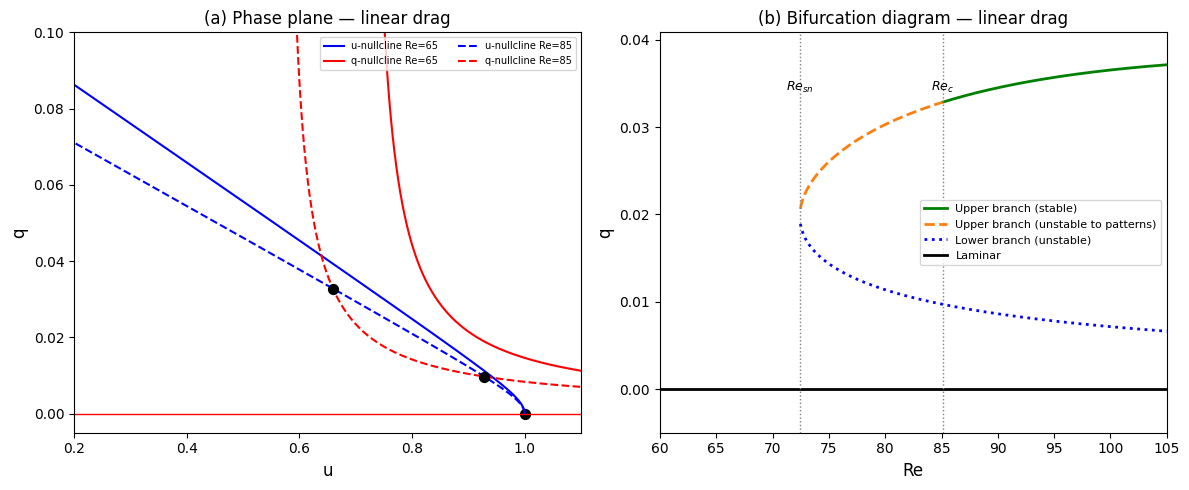


Computing Figure 10 — linear drag
  Panel (a): Re=73.0, full system
  Panel (b): Re=84.7, full system
  Panel (c): Re=84.7, long-wavelength


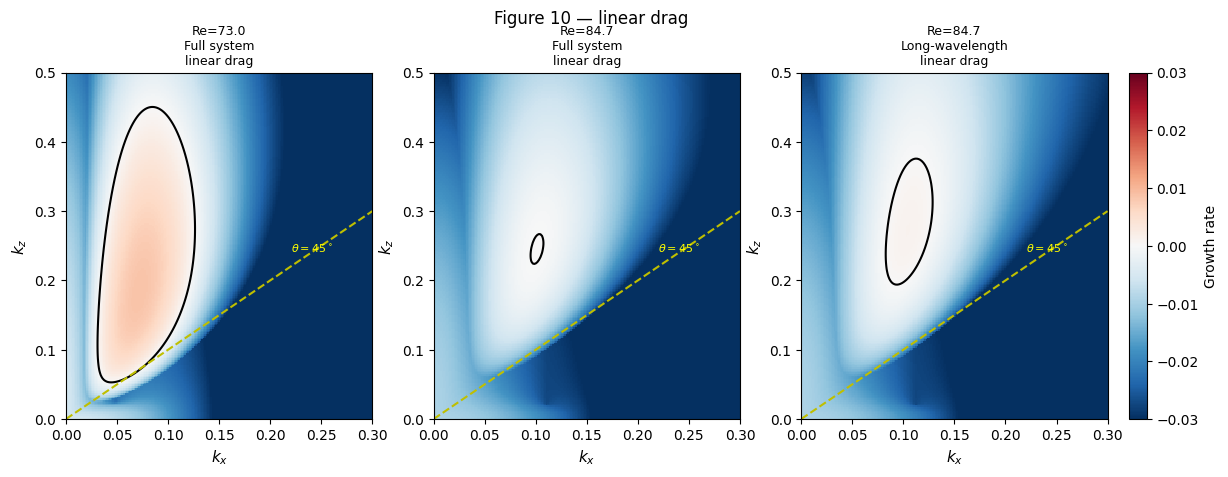

In [11]:
plot_figure6( drag= DRAG_LINEAR,Re_low = 65,Re_high = 85,Rec = 85.1,Re_sn = 72.4)

plot_figure10( drag= DRAG_LINEAR,Re_stable   = 73.0,Re_unstable = 84.7)

In [9]:
def viability_scan(drag, Re_range): 

    print(f"\nViability scan — {drag['name']} drag")
    print(f"  alpha = {drag['alpha']:.5f},  "
          f"h(1) = {float(drag['h'](1.0)):.4f},  "
          f"dh(1) = {float(drag['dh'](np.array([1.0]))[0]):.4f}")
    
    print(f"\n{'Re':>6}  {'max_growth':>12}  {'status':>15}")
    print("-" * 45)

    # Coarse wavenumber grid
    kx_test = np.linspace(0.001, 0.3, 60)
    kz_test = np.linspace(0.001, 0.5, 60)

    results = []

    for Re in Re_range:

        uss, qss = find_upper_branch(Re, drag)

        if uss is None:
            # No turbulent state
            results.append((Re, None))
            continue

        try:
            G     = compute_growth_map(kx_test, kz_test, Re, drag, lw=False)
            max_g = np.max(G)
        except Exception:
            results.append((Re, None))
            continue

        results.append((Re, max_g))

    # Find Re_c
    rec_idx = None
    for i in range(len(results) - 1):
        Re_i,   mg_i   = results[i]
        Re_ip1, mg_ip1 = results[i+1]

        if mg_i is not None and mg_ip1 is not None:
            if mg_i > 0 and mg_ip1 <= 0:
                rec_idx = i

    # Print results table
    for idx, (Re, max_g) in enumerate(results):

        if max_g is None:
            print(f"{Re:>6}  {'---':>12}  {'no turb state':>15}")
            continue

        # Status label
        if idx == rec_idx:
            status = f"Re_c ~ {results[idx+1][0]}"
        elif max_g > 0:
            status = "unstable (bands)"
        else:
            status = "stable"

        print(f"{Re:>6}  {max_g:>12.5f}  {status:>15}")

    # Summary
    print("\nSummary:")

    # Re_sn
    no_turb  = [r[0] for r in results if r[1] is None]
    has_turb = [r[0] for r in results if r[1] is not None]

    if no_turb and has_turb:
        print(f"  Re_sn is between Re={max(no_turb)} and Re={min(has_turb)}")
        print(f"  Use Re_low  = {min(has_turb)} for Figure 6 phase plane")
        print(f"  Use Re_stable = {min(has_turb)} for Figure 10 panel (a)")

    # Re_c
    if rec_idx is not None:
        Re_below = results[rec_idx][0]
        Re_above = results[rec_idx+1][0]
        print(f"  Re_c is between Re={Re_below} and Re={Re_above}")
        print(f"  Use Re_high     = {Re_below} for Figure 6 phase plane")
        print(f"  Use Rec         = {Re_below} for Figure 6 bifurcation diagram")
        print(f"  Use Re_unstable = {Re_below} for Figure 10 panels (b) and (c)")
    else:
        print("  Re_c not found in this scan range — extend Re_range upward")

In [10]:
test_alphas = [0.003, 0.004, 0.005, 0.006, 0.007, 0.008]

for alpha_test in test_alphas:
    drag = {
        'name'  : f'cubic_a{alpha_test:.3f}',
        'alpha' : alpha_test,
        'alpha0': 3 * alpha_test,    # keep ratio fixed at 3
        'h'     : lambda u: np.abs(u)**2 * u,
        'dh'    : lambda u: 3*np.atleast_1d(np.array(u, dtype=float))**2,
    }
    viability_scan(drag, np.arange(65, 130, 5))


Viability scan — cubic_a0.003 drag
  alpha = 0.00300,  h(1) = 1.0000,  dh(1) = 3.0000

    Re    max_growth           status
---------------------------------------------
    65           ---    no turb state
    70       0.00880  unstable (bands)
    75       0.00809  unstable (bands)
    80       0.00778  unstable (bands)
    85       0.00758  unstable (bands)
    90       0.00743  unstable (bands)
    95       0.00728  unstable (bands)
   100       0.00713  unstable (bands)
   105       0.00697  unstable (bands)
   110       0.00681  unstable (bands)
   115       0.00665  unstable (bands)
   120       0.00649  unstable (bands)
   125       0.00633  unstable (bands)

Summary:
  Re_sn is between Re=65 and Re=70
  Use Re_low  = 70 for Figure 6 phase plane
  Use Re_stable = 70 for Figure 10 panel (a)
  Re_c not found in this scan range — extend Re_range upward

Viability scan — cubic_a0.004 drag
  alpha = 0.00400,  h(1) = 1.0000,  dh(1) = 3.0000

    Re    max_growth           status
-

In [16]:
for alpha_test in [0.004, 0.005, 0.006, 0.007, 0.008, 0.009]:
    drag = {
        'name'  : f'quadratic_a{alpha_test:.3f}',
        'alpha' : alpha_test,
        'alpha0': 3 * alpha_test,
        'h'     : lambda u: u * np.abs(u),
        'dh'    : lambda u: 2*np.abs(
                      np.atleast_1d(np.array(u, dtype=float))),
    }
    viability_scan(drag, np.arange(65, 130, 5))


Viability scan — quadratic_a0.004 drag
  alpha = 0.00400,  h(1) = 1.0000,  dh(1) = 2.0000

    Re    max_growth           status
---------------------------------------------
    65           ---    no turb state
    70       0.00793  unstable (bands)
    75       0.00663  unstable (bands)
    80       0.00608  unstable (bands)
    85       0.00576  unstable (bands)
    90       0.00553  unstable (bands)
    95       0.00534  unstable (bands)
   100       0.00516  unstable (bands)
   105       0.00499  unstable (bands)
   110       0.00483  unstable (bands)
   115       0.00467  unstable (bands)
   120       0.00452  unstable (bands)
   125       0.00437  unstable (bands)

Summary:
  Re_sn is between Re=65 and Re=70
  Use Re_low  = 70 for Figure 6 phase plane
  Use Re_stable = 70 for Figure 10 panel (a)
  Re_c not found in this scan range — extend Re_range upward

Viability scan — quadratic_a0.005 drag
  alpha = 0.00500,  h(1) = 1.0000,  dh(1) = 2.0000

    Re    max_growth           

In [14]:
for alpha_test in [0.007, 0.008, 0.009, 0.010, 0.011]:
    _lc   = 0.1
    _norm = 1 + _lc
    drag = {
        'name'  : f'lc_a{alpha_test:.3f}',
        'alpha' : alpha_test,
        'alpha0': 3 * alpha_test,
        'h'     : lambda u: (u + _lc*np.abs(u)**2*u) / _norm,
        'dh'    : lambda u: (1 + 3*_lc*np.atleast_1d(
                      np.array(u, dtype=float))**2) / _norm,
    }
    viability_scan(drag, np.arange(65, 130, 5))


Viability scan — lc_a0.007 drag
  alpha = 0.00700,  h(1) = 1.0000,  dh(1) = 1.1818

    Re       uss         qss    max_growth           status
------------------------------------------------------------
    65       ---         ---           ---    no turb state
    70    0.8047     0.02234       0.01077  unstable (bands)
    75    0.7199     0.02876       0.00523  unstable (bands)
    80    0.6684     0.03173       0.00371  unstable (bands)
    85    0.6277     0.03360       0.00290  unstable (bands)
    90    0.5936     0.03484       0.00235  unstable (bands)
    95    0.5641     0.03567       0.00192  unstable (bands)
   100    0.5382     0.03621       0.00158  unstable (bands)
   105    0.5151     0.03655       0.00128  unstable (bands)
   110    0.4945     0.03674       0.00099  unstable (bands)
   115    0.4758     0.03681       0.00075  unstable (bands)
   120    0.4588     0.03680       0.00050  unstable (bands)
   125    0.4433     0.03673       0.00028  unstable (bands)

S

In [12]:
_lc   = 0.1
_norm = 1 + _lc

DRAG_LINEAR_CUBIC_FINAL = {
    'name'  : 'linear_cubic_final',
    'alpha' : 0.009,
    'alpha0': 0.027,        # 3 * alpha as agreed
    'h'     : lambda u: (u + _lc * np.abs(u)**2 * u) / _norm,
    'dh'    : lambda u: (1 + 3*_lc * np.atleast_1d(
                  np.array(u, dtype=float))**2) / _norm,
}

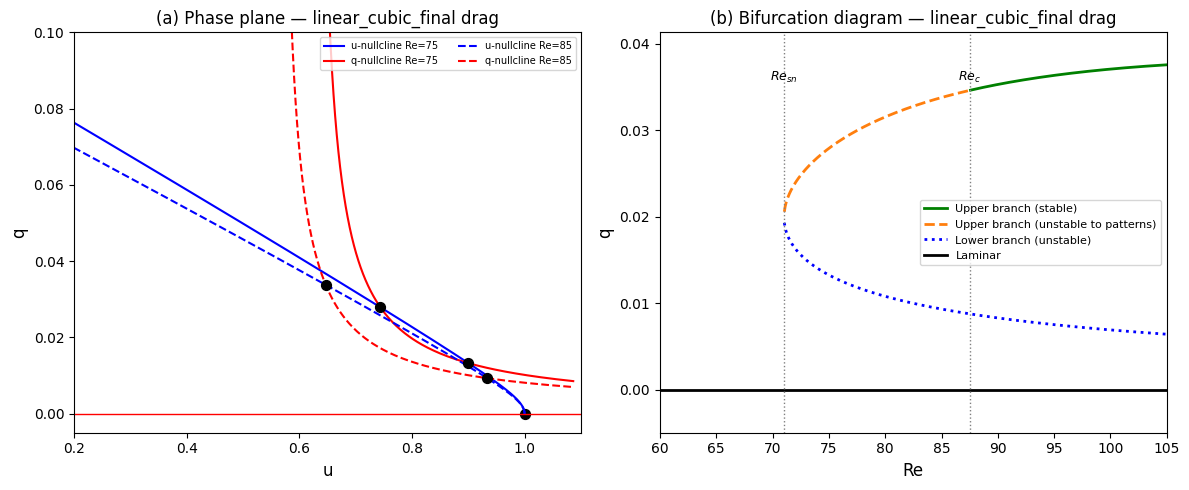

In [15]:
plot_figure6(  drag    = DRAG_LINEAR_CUBIC_FINAL,
               Re_low  = 75,      # just above Re_sn
               Re_high = 85,      # just below Re_c
               Rec     = 87.5,    # midpoint of 85-90 range
               Re_sn   = 71.0)    # midpoint of 70-75 range

# plot_figure10( drag        = DRAG_LINEAR_CUBIC_FINAL,
#                Re_stable   = 75,  # just above Re_sn, should be all blue
#                Re_unstable = 85)  # just below Re_c, should show red blob

In [ ]:
for alpha_test in [0.008, 0.009, 0.010, 0.011]:
    _lq   = 0.1       # quadratic coefficient — same as cubic for fair comparison
    _norm = 1 + _lq   # normalisation so h(1) = 1

    drag = {
        'name'  : f'linear_quad_a{alpha_test:.3f}',
        'alpha' : alpha_test,
        'alpha0': 3 * alpha_test,
        'h'     : lambda u: (u + _lq * u * np.abs(u)) / _norm,
        'dh'    : lambda u: (1 + 2*_lq * np.abs(
                      np.atleast_1d(np.array(u, dtype=float)))) / _norm,
    }
    viability_scan(drag, np.arange(65, 130, 5))


Viability scan — linear_quad_a0.008 drag
  alpha = 0.00800,  h(1) = 1.0000,  dh(1) = 1.0909

    Re       uss         qss    max_growth           status
------------------------------------------------------------
    65       ---         ---           ---    no turb state
    70       ---         ---           ---    no turb state
    75    0.7333     0.02800       0.00467  unstable (bands)
    80    0.6797     0.03134       0.00273  unstable (bands)
    85    0.6381     0.03342       0.00176  unstable (bands)
    90    0.6034     0.03481       0.00113  unstable (bands)
    95    0.5736     0.03577       0.00065  unstable (bands)
   100    0.5475     0.03642       0.00027       Re_c ~ 105
   105    0.5243     0.03684      -0.00005           stable
   110    0.5035     0.03711      -0.00035           stable
   115    0.4848     0.03726      -0.00061           stable
   120    0.4677     0.03731      -0.00085           stable
   125    0.4521     0.03730      -0.00108           stable


In [ ]:
_lq = 0.1; _lq_norm = 1 + _lq
DRAG_LINEAR_QUAD_FINAL = {
    'name'  : 'linear_quadratic',
    'alpha' : 0.009,
    'alpha0': 0.027,
    'h'     : lambda u: (u + _lq*u*np.abs(u)) / _lq_norm,
    'dh'    : lambda u: (1 + 2*_lq*np.abs(
                  np.atleast_1d(np.array(u, dtype=float)))) / _lq_norm,
}

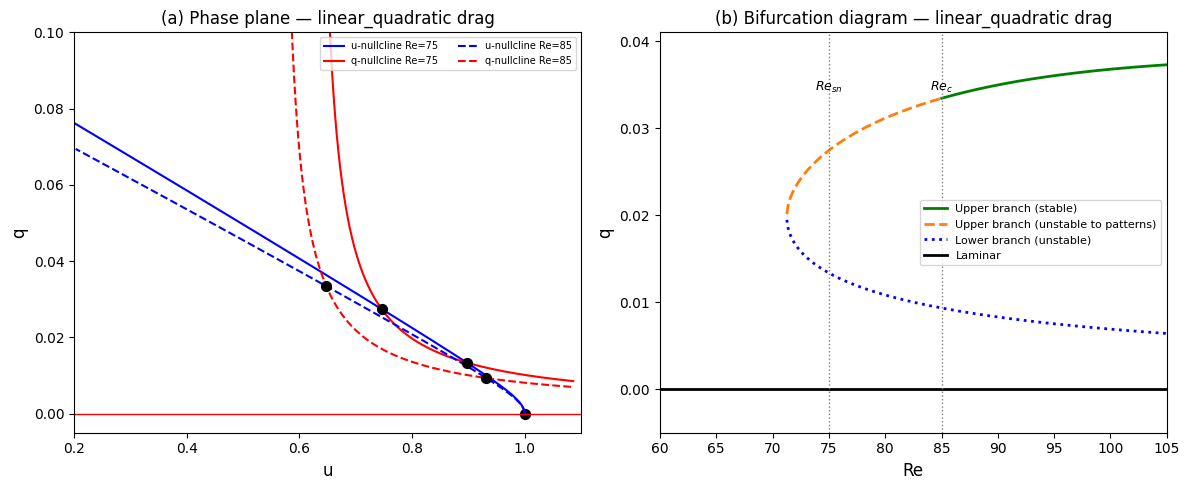


Computing Figure 10 — linear_quadratic drag
  Panel (a): Re=75, full system
  Panel (b): Re=85, full system
  Panel (c): Re=85, long-wavelength


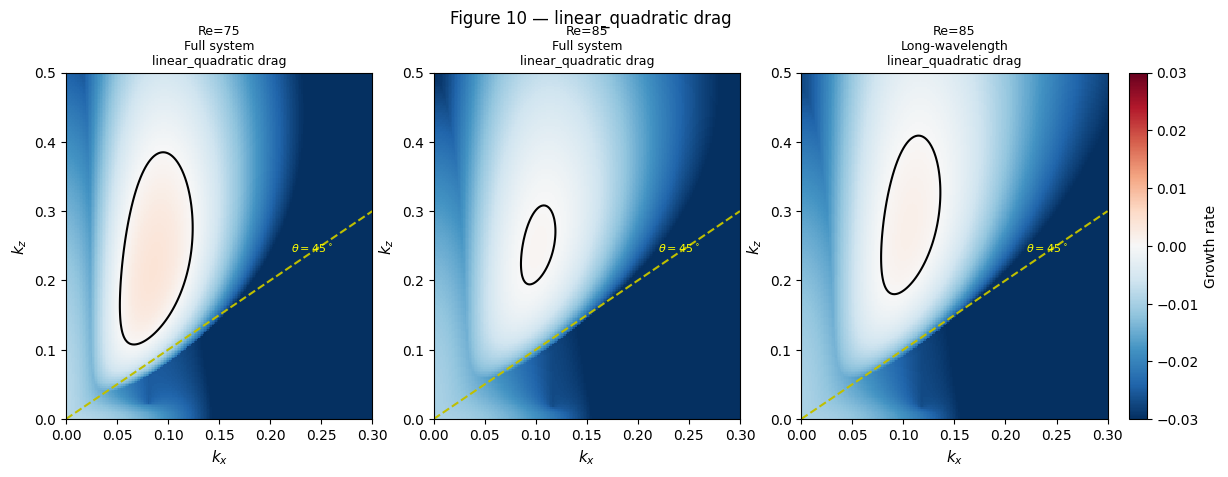

In [ ]:
plot_figure6(drag=DRAG_LINEAR_QUAD_FINAL,Re_low=75, Re_high= 85, Rec= 85, Re_sn=75)
plot_figure10(drag=DRAG_LINEAR_QUAD_FINAL,Re_stable=75,Re_unstable=85)